# EV Fleet Weather Dataset Analysis
### Correlation Analysis, Visualization & Model Training (R² Evaluation)

## 1. Import Required Libraries

In [1]:
print("heel")

heel


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

# Notebook display settings
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and Explore the Dataset

In [3]:
df = pd.read_csv('ev_fleet_dataset_weather.csv')

print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
df.head()

Shape: (24200, 34)

Column names:
['Record_ID', 'Date', 'Time', 'Admin_ID', 'Driver_ID', 'Vehicle_ID', 'Brand', 'Vehicle_Model', 'Category', 'Max_Range_km', 'Battery_Capacity_kWh', 'Vehicle_Weight_kg', 'Motor_Spec_kW', 'Battery_Percentage', 'Battery_Health_Percentage', 'Passenger_Count', 'Total_Load_Weight_kg', 'Road_Type', 'Vehicle_Status', 'Speed_kmph', 'Overspeed', 'Distance_Travelled_km', 'Odometer_km', 'Energy_Consumed_kWh', 'Charging_Status', 'Charge_Cycle_Count', 'Workshop_Visit', 'Maintenance_Cost', 'OT_Maintenance_Cost', 'Breakdown', 'Income_Generated', 'Total_Expense', 'Weather', 'Remaining_Range_km']


,Record_ID,Date,Time,Admin_ID,Driver_ID,Vehicle_ID,Brand,Vehicle_Model,Category,Max_Range_km,Battery_Capacity_kWh,Vehicle_Weight_kg,Motor_Spec_kW,Battery_Percentage,Battery_Health_Percentage,Passenger_Count,Total_Load_Weight_kg,Road_Type,Vehicle_Status,Speed_kmph,Overspeed,Distance_Travelled_km,Odometer_km,Energy_Consumed_kWh,Charging_Status,Charge_Cycle_Count,Workshop_Visit,Maintenance_Cost,OT_Maintenance_Cost,Breakdown,Income_Generated,Total_Expense,Weather,Remaining_Range_km
0,1,2026-02-09,08:00:00,A003,1,EV001,Tata,Tata Tiago EV,Hatchback,285,24.0,1235,55,52.71,95,5,355,Mixed,Running,62,No,70.94,23596.94,5.83,No,130,No,0,0,No,756.21,88.43,2,110.00
1,2,2026-02-09,11:00:00,A003,1,EV001,Tata,Tata Tiago EV,Hatchback,285,24.0,1235,55,25.92,95,1,71,Highway,Running,122,Yes,75.04,23671.98,6.43,No,130,No,0,0,No,847.29,104.65,0,39.16
2,3,2026-02-09,14:00:00,A003,1,EV001,Tata,Tata Tiago EV,Hatchback,285,24.0,1235,55,5.21,95,1,78,City,Running,87,Yes,63.61,23735.59,4.97,No,130,No,0,0,No,666.31,70.71,0,12.13
3,4,2026-02-09,17:00:00,A003,1,EV001,Tata,Tata Tiago EV,Hatchback,285,24.0,1235,55,41.60,95,0,0,NaN,Charging,0,No,0.00,23735.59,0.00,Yes,130,No,0,0,No,0.00,0.00,1,135.24
4,5,2026-02-09,20:00:00,A003,1,EV001,Tata,Tata Tiago EV,Hatchback,285,24.0,1235,55,78.00,95,0,0,NaN,Charging,0,No,0.00,23735.59,0.00,Yes,131,No,0,0,No,0.00,0.00,2,176.89


In [4]:
print("Dataset Info:")
df.info()
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24200 entries, 0 to 24199
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Record_ID                  24200 non-null  int64  
 1   Date                       24200 non-null  object 
 2   Time                       24200 non-null  object 
 3   Admin_ID                   24200 non-null  object 
 4   Driver_ID                  24200 non-null  int64  
 5   Vehicle_ID                 24200 non-null  object 
 6   Brand                      24200 non-null  object 
 7   Vehicle_Model              24200 non-null  object 
 8   Category                   24200 non-null  object 
 9   Max_Range_km               24200 non-null  int64  
 10  Battery_Capacity_kWh       24200 non-null  float64
 11  Vehicle_Weight_kg          24200 non-null  int64  
 12  Motor_Spec_kW              24200 non-null  int64  
 13  Battery_Percentage         24200

,Record_ID,Driver_ID,Max_Range_km,Battery_Capacity_kWh,Vehicle_Weight_kg,Motor_Spec_kW,Battery_Percentage,Battery_Health_Percentage,Passenger_Count,Total_Load_Weight_kg,Speed_kmph,Distance_Travelled_km,Odometer_km,Energy_Consumed_kWh,Charge_Cycle_Count,Maintenance_Cost,OT_Maintenance_Cost,Income_Generated,Total_Expense,Weather,Remaining_Range_km
count,24200.000000,24200.000000,24200.00000,24200.000000,24200.000000,24200.000000,24200.000000,24200.000000,24200.000000,24200.000000,24200.000000,24200.000000,24200.000000,24200.000000,24200.000000,24200.000000,24200.000000,24200.000000,24200.000000,24200.000000,24200.000000
mean,12100.500000,20.500000,585.42500,69.400000,2014.625000,166.125000,48.401473,93.794835,2.366612,177.455992,54.395124,33.966346,35441.757254,3.704537,167.000083,123.784545,69.954132,409.998926,273.747402,1.505826,219.629143
std,6986.082593,11.543635,187.91036,32.933035,498.368084,73.575356,20.322272,2.988485,1.906763,143.266300,37.845066,26.222481,14326.079600,3.054959,74.506564,1097.413910,615.756956,344.789942,1680.913302,1.118190,130.204923
min,1.000000,1.000000,285.00000,24.000000,1235.000000,55.000000,0.000000,88.000000,0.000000,0.000000,0.000000,0.000000,2140.870000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6050.750000,10.750000,456.00000,39.400000,1585.000000,90.000000,32.957500,91.000000,1.000000,70.000000,25.000000,10.320000,24977.282500,0.880000,111.000000,0.000000,0.000000,92.975000,17.802500,1.000000,121.940000
50%,12100.500000,20.500000,538.00000,75.000000,2175.000000,175.000000,48.250000,94.000000,2.000000,156.000000,61.000000,33.635000,36271.520000,3.480000,169.000000,0.000000,0.000000,377.680000,76.285000,2.000000,195.420000
75%,18150.250000,30.250000,717.25000,86.200000,2270.000000,218.750000,63.970000,96.000000,4.000000,300.000000,83.000000,56.960000,46387.120000,5.890000,231.000000,0.000000,0.000000,641.580000,159.740000,3.000000,294.195000
max,24200.000000,40.000000,857.00000,122.000000,2810.000000,265.000000,97.080000,100.000000,7.000000,560.000000,130.000000,80.000000,65636.010000,14.250000,311.000000,14978.000000,7993.000000,1350.370000,36264.180000,3.000000,831.290000


## 3. Data Cleaning and Preprocessing

In [ ]:
# Drop non-informative / identifier columns
# Also remove the features we no longer want the model to depend on.
drop_cols = ['Record_ID', 'Date', 'Time', 'Admin_ID', 'Driver_ID', 'Vehicle_ID',
             'Brand', 'Vehicle_Status', 'Speed_kmph', 'Overspeed',
             'Charging_Status', 'OT_Maintenance_Cost', 'Income_Generated', 'Total_Expense',
             'Breakdown', 'Energy_Consumed_kWh', 'Workshop_Visit', 'Maintenance_Cost']

print('Current columns before drop:')
print(df.columns.tolist())
print(f'Total columns before drop: {len(df.columns)}')
print('\nColumns scheduled for drop:')
print([c for c in drop_cols if c in df.columns])

df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Encode binary Yes/No columns
yes_no_cols = ['Overspeed', 'Charging_Status', 'Workshop_Visit', 'Breakdown']
for col in yes_no_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

# Encode remaining object columns with Label Encoding
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_clean[col] = df_clean[col].astype('category').cat.codes

# Drop rows with missing target
df_clean.dropna(subset=['Remaining_Range_km'], inplace=True)

# Fill any remaining NaN with median
df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)

print(f"\nCleaned shape: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
df_clean.head()

Cleaned shape: (24200, 26)

Missing values: 0


,Category,Max_Range_km,Battery_Capacity_kWh,Vehicle_Weight_kg,Motor_Spec_kW,Battery_Percentage,Battery_Health_Percentage,Passenger_Count,Total_Load_Weight_kg,Road_Type,Vehicle_Status,Speed_kmph,Overspeed,Distance_Travelled_km,Odometer_km,Energy_Consumed_kWh,Charging_Status,Charge_Cycle_Count,Workshop_Visit,Maintenance_Cost,OT_Maintenance_Cost,Breakdown,Income_Generated,Total_Expense,Weather,Remaining_Range_km
0,0,285,24.0,1235,55,52.71,95,5,355,2,1,62,0,70.94,23596.94,5.83,0,130,0,0,0,0,756.21,88.43,2,110.00
1,0,285,24.0,1235,55,25.92,95,1,71,1,1,122,1,75.04,23671.98,6.43,0,130,0,0,0,0,847.29,104.65,0,39.16
2,0,285,24.0,1235,55,5.21,95,1,78,0,1,87,1,63.61,23735.59,4.97,0,130,0,0,0,0,666.31,70.71,0,12.13
3,0,285,24.0,1235,55,41.60,95,0,0,-1,0,0,0,0.00,23735.59,0.00,1,130,0,0,0,0,0.00,0.00,1,135.24
4,0,285,24.0,1235,55,78.00,95,0,0,-1,0,0,0,0.00,23735.59,0.00,1,131,0,0,0,0,0.00,0.00,2,176.89


## 4. Visualize the Dataset

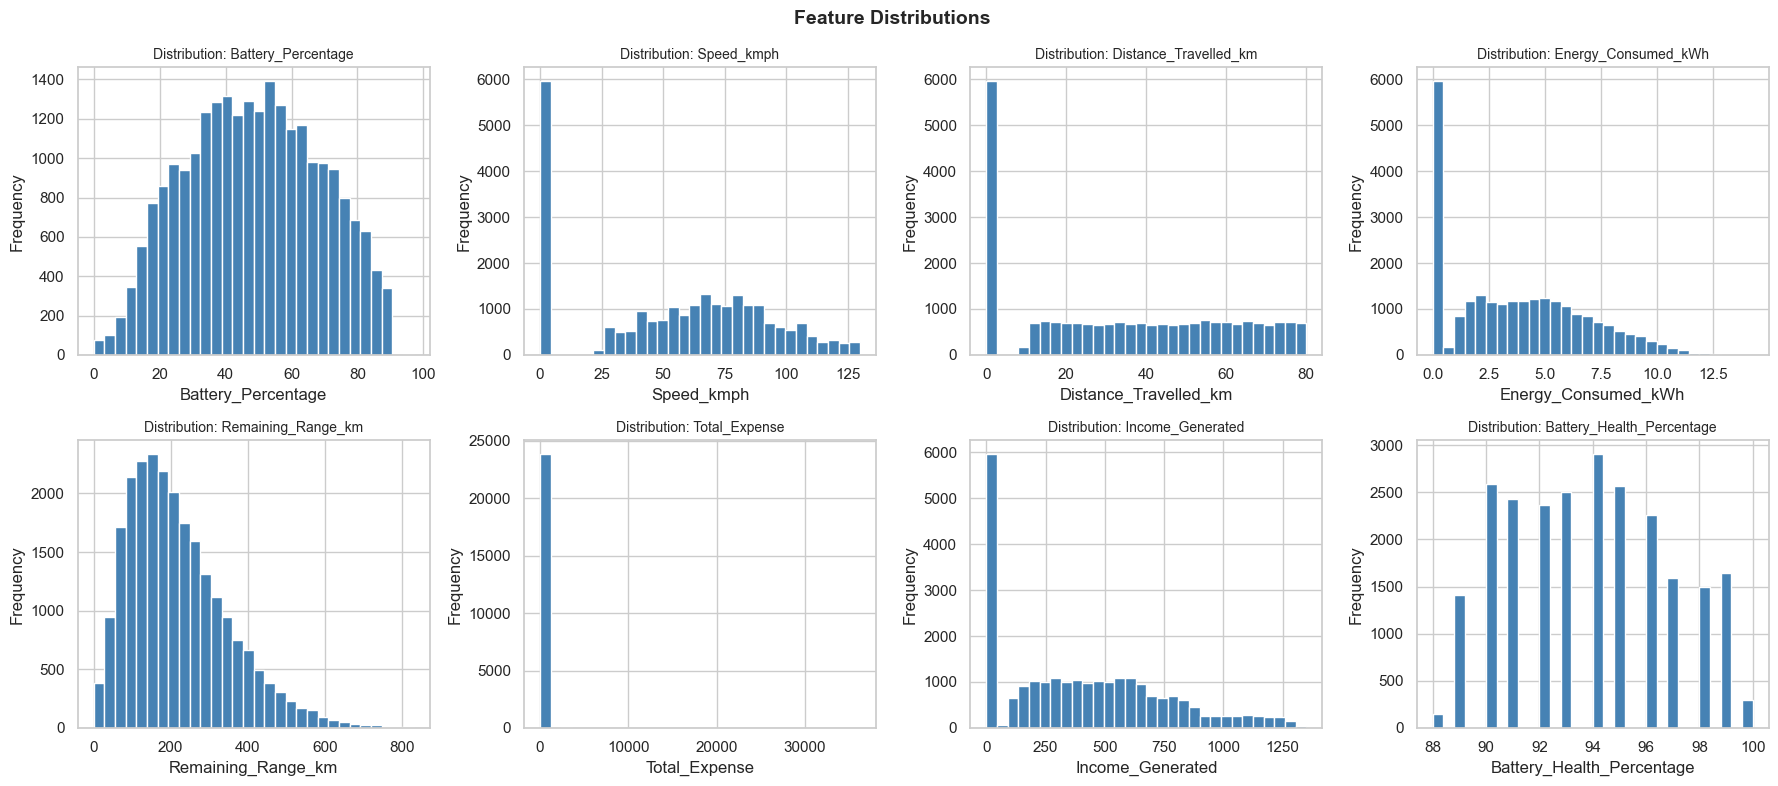

In [6]:
# Key numeric columns to visualize
key_cols = ['Battery_Percentage', 'Speed_kmph', 'Distance_Travelled_km',
            'Energy_Consumed_kWh', 'Remaining_Range_km', 'Total_Expense',
            'Income_Generated', 'Battery_Health_Percentage']

key_cols = [c for c in key_cols if c in df_clean.columns]

# Histograms
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(key_cols):
    axes[i].hist(df_clean[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution: {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# # Boxplots to identify outliers
# fig, axes = plt.subplots(2, 4, figsize=(18, 8))
# axes = axes.flatten()
# for i, col in enumerate(key_cols):
#     axes[i].boxplot(df_clean[col].dropna(), patch_artist=True,
#                     boxprops=dict(facecolor='lightblue', color='navy'))
#     axes[i].set_title(f'Boxplot: {col}', fontsize=10)
#     axes[i].set_ylabel(col)
# plt.suptitle('Feature Boxplots (Outlier Detection)', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

## 5. Correlation Matrix Heatmap

In [20]:
# corr_matrix = df_clean.corr(numeric_only=True)

# plt.figure(figsize=(18, 14))
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
# sns.heatmap(
#     corr_matrix,
#     mask=mask,
#     annot=True,
#     fmt='.2f',
#     cmap='coolwarm',
#     center=0,
#     linewidths=0.5,
#     linecolor='grey',
#     annot_kws={'size': 7},
#     square=True,
#     cbar_kws={'shrink': 0.8}
# )
# plt.title('Full Correlation Matrix — EV Fleet Weather Dataset', fontsize=15, fontweight='bold', pad=15)
# plt.xticks(rotation=45, ha='right', fontsize=8)
# plt.yticks(rotation=0, fontsize=8)
# plt.tight_layout()
# plt.show()

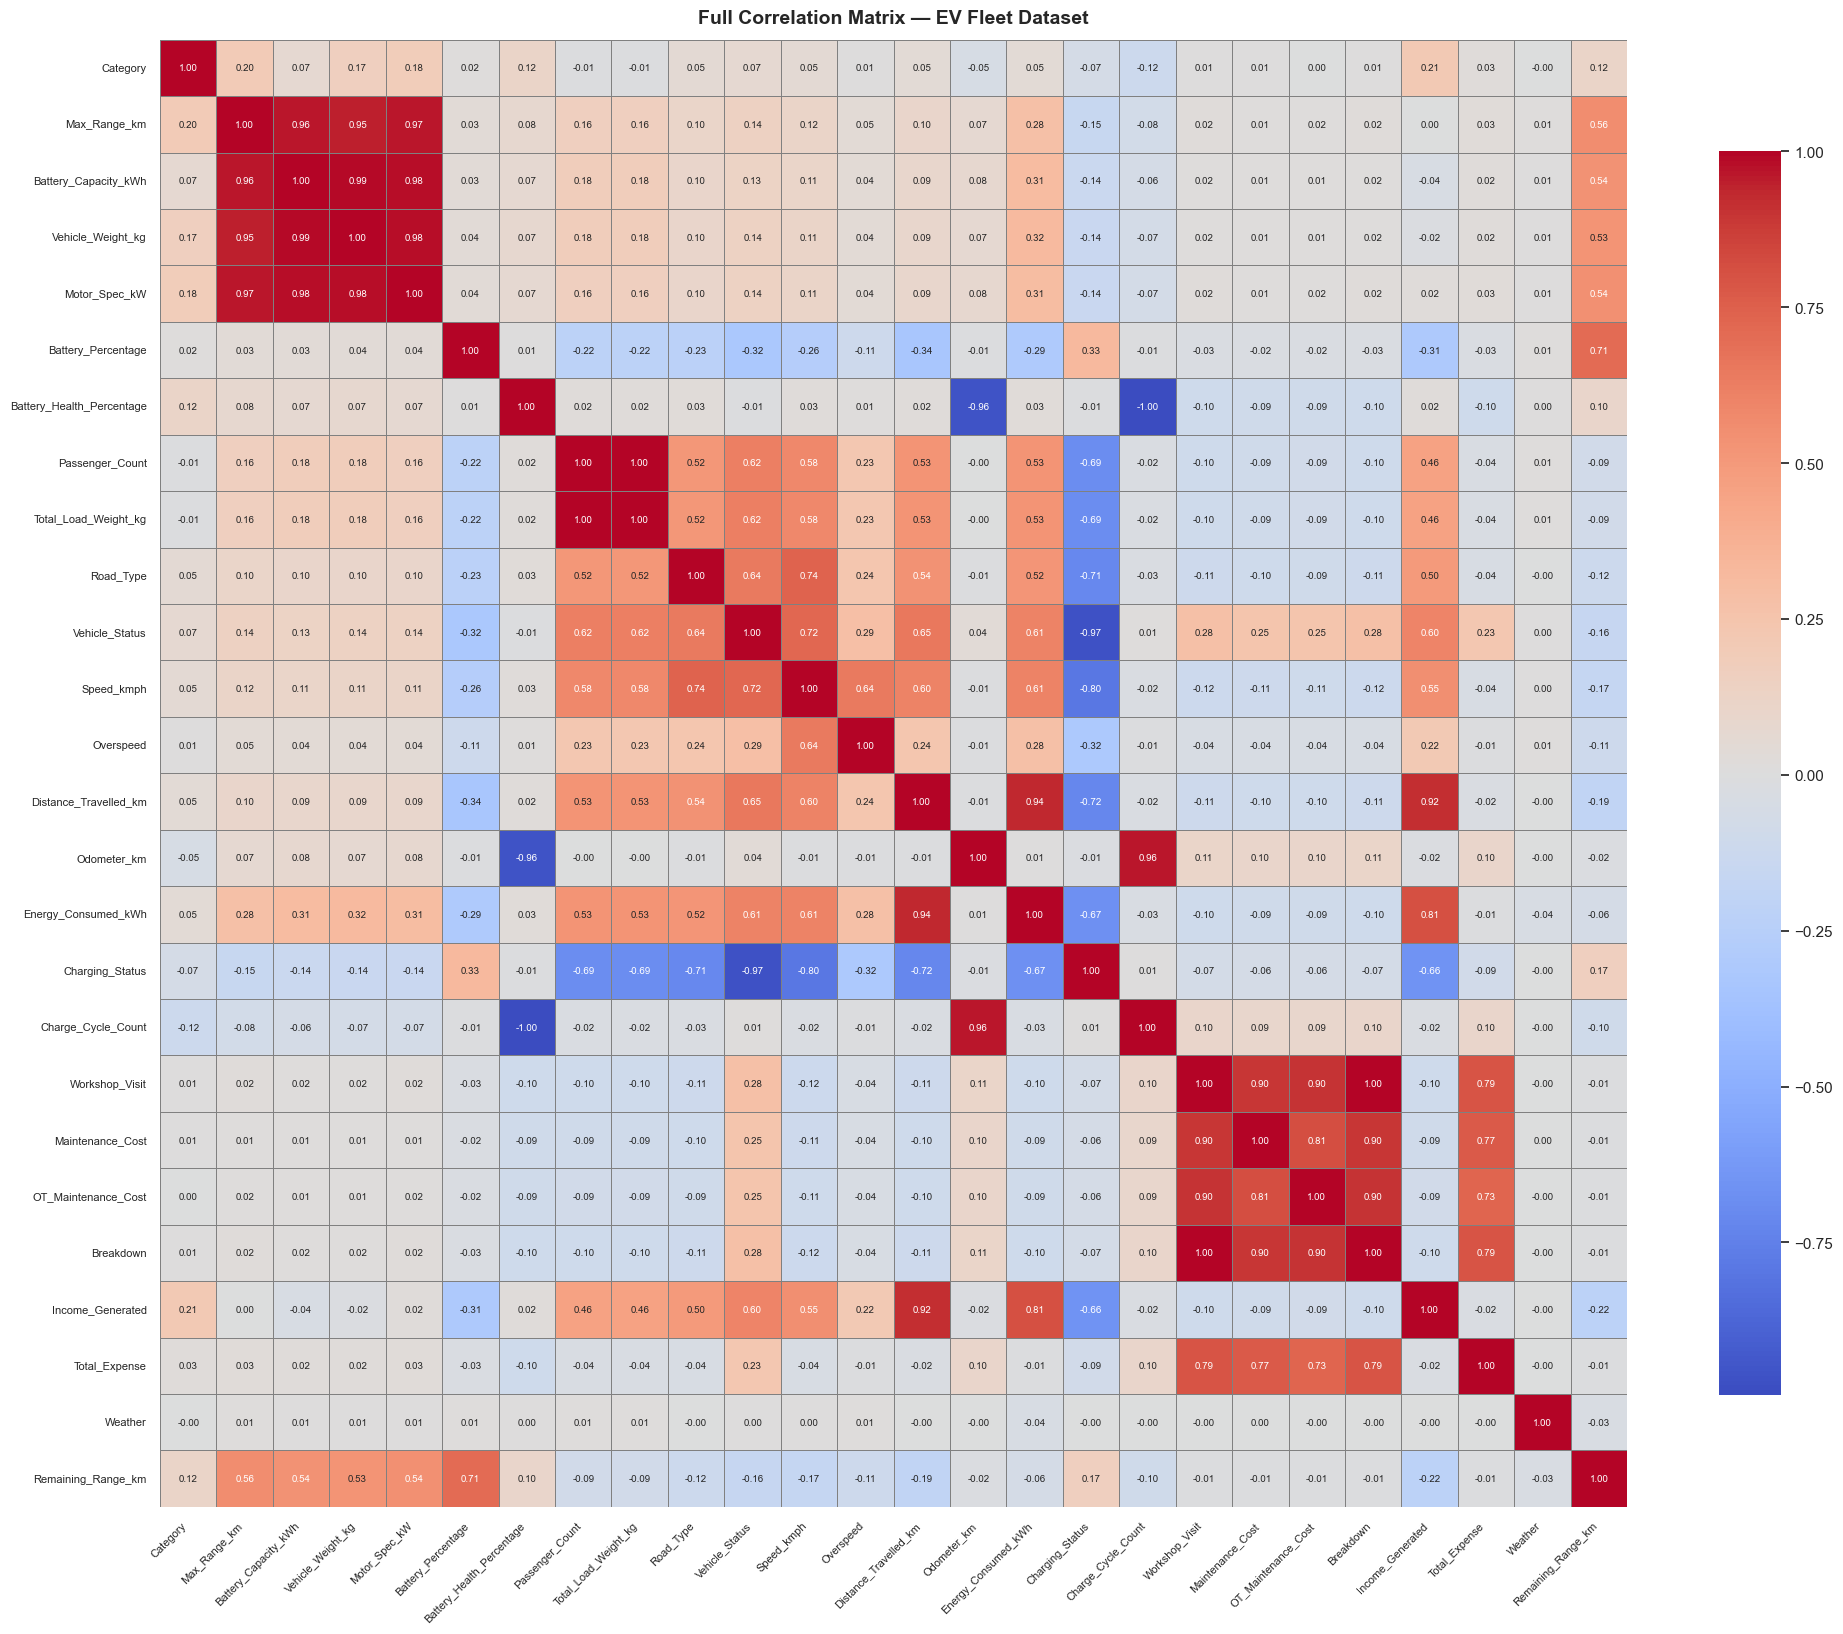


Matrix shape: (26, 26)  (26 features x 26 features)


In [9]:
corr_matrix = df_clean.corr(numeric_only=True)

n = len(corr_matrix.columns)
fig, ax = plt.subplots(figsize=(n * 0.7 + 2, n * 0.6 + 2))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.4,
    linecolor='grey',
    annot_kws={'size': 7},
    square=True,
    cbar_kws={'shrink': 0.75},
    ax=ax
)
ax.set_title('Full Correlation Matrix — EV Fleet Dataset', fontsize=14, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nMatrix shape: {corr_matrix.shape}  ({n} features x {n} features)")

In [21]:
# col = 'Remaining_Range_km'
# rr = df_clean[col]

# zero_count = (rr == 0).sum()
# total = len(rr)
# print(f"Total records : {total}")
# print(f"Zero values   : {zero_count}  ({zero_count/total*100:.2f}%)")
# print(f"Non-zero min  : {rr[rr > 0].min():.2f}")
# print(f"Max           : {rr.max():.2f}")
# print(f"Mean          : {rr.mean():.2f}")
# print(f"Median        : {rr.median():.2f}")

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# # ── 1. Histogram with zero highlighted ─────────────────────────────────────
# axes[0].hist(rr[rr > 0], bins=40, color='steelblue', edgecolor='white', label='Non-zero')
# axes[0].axvline(0, color='red', linewidth=0, label='')  # placeholder
# axes[0].bar(0, zero_count, width=rr.max()/60, color='red', label=f'Zero ({zero_count})')
# axes[0].set_title('Remaining Range — Distribution\n(zeros highlighted in red)', fontsize=12, fontweight='bold')
# axes[0].set_xlabel('Remaining_Range_km')
# axes[0].set_ylabel('Count')
# axes[0].legend()

# # ── 2. Boxplot ──────────────────────────────────────────────────────────────
# axes[1].boxplot(rr, patch_artist=True,
#                 boxprops=dict(facecolor='lightsteelblue', color='navy'),
#                 medianprops=dict(color='red', linewidth=2),
#                 flierprops=dict(marker='o', color='orange', alpha=0.4, markersize=3))
# axes[1].set_title('Remaining Range — Boxplot', fontsize=12, fontweight='bold')
# axes[1].set_ylabel('Remaining_Range_km')
# axes[1].set_xticks([])

# # ── 3. Zero vs Non-zero pie ─────────────────────────────────────────────────
# axes[2].pie(
#     [zero_count, total - zero_count],
#     labels=[f'Zero\n({zero_count})', f'Non-zero\n({total - zero_count})'],
#     colors=['#d62728', 'steelblue'],
#     autopct='%1.1f%%',
#     startangle=90,
#     wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
# )
# axes[2].set_title('Zero vs Non-zero\nRemaining_Range_km', fontsize=12, fontweight='bold')

# plt.suptitle('Remaining_Range_km — Deep Dive (Zero Analysis)', fontsize=14, fontweight='bold', y=1.01)
# plt.tight_layout()
# plt.show()

In [22]:
# zero_range = df_clean[df_clean['Remaining_Range_km'] == 0]['Battery_Percentage']

# print("=== Battery % when Remaining_Range_km == 0 ===")
# print(f"Count          : {len(zero_range)}")
# print(f"Min Battery %  : {zero_range.min():.2f}")
# print(f"Max Battery %  : {zero_range.max():.2f}")
# print(f"Mean Battery % : {zero_range.mean():.2f}")
# print(f"Median Battery%: {zero_range.median():.2f}")
# print(f"\nAll values:\n{zero_range.sort_values().values}")

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # ── 1. Scatter: Battery % vs Remaining Range (zeros highlighted) ───────────
# non_zero = df_clean[df_clean['Remaining_Range_km'] > 0].sample(min(2000, len(df_clean)), random_state=42)
# zero_pts  = df_clean[df_clean['Remaining_Range_km'] == 0]

# axes[0].scatter(non_zero['Battery_Percentage'], non_zero['Remaining_Range_km'],
#                 alpha=0.2, s=10, color='steelblue', label='Non-zero range')
# axes[0].scatter(zero_pts['Battery_Percentage'], zero_pts['Remaining_Range_km'],
#                 alpha=0.9, s=60, color='red', marker='X', zorder=5,
#                 label=f'Range = 0  (n={len(zero_pts)})')
# axes[0].set_xlabel('Battery_Percentage (%)', fontsize=11)
# axes[0].set_ylabel('Remaining_Range_km', fontsize=11)
# axes[0].set_title('Battery % vs Remaining Range\n(red ✕ = zero range records)', fontsize=12, fontweight='bold')
# axes[0].legend()

# # ── 2. Histogram of Battery % for zero-range records ──────────────────────
# axes[1].hist(zero_range, bins=20, color='red', edgecolor='white', alpha=0.8)
# axes[1].set_xlabel('Battery_Percentage (%)', fontsize=11)
# axes[1].set_ylabel('Count', fontsize=11)
# axes[1].set_title('Distribution of Battery %\nwhen Remaining_Range_km = 0', fontsize=12, fontweight='bold')
# for v in [zero_range.mean()]:
#     axes[1].axvline(v, color='black', linestyle='--', linewidth=1.5, label=f'Mean = {v:.1f}%')
# axes[1].legend()

# plt.tight_layout()
# plt.show()

In [23]:
# breakdown_rr  = df_clean[df_clean['Breakdown']       == 1]['Remaining_Range_km']
# charging_rr   = df_clean[df_clean['Charging_Status'] == 1]['Remaining_Range_km']
# normal_rr     = df_clean[(df_clean['Breakdown'] == 0) & (df_clean['Charging_Status'] == 0)]['Remaining_Range_km']

# for label, series in [('BREAKDOWN (Yes)', breakdown_rr),
#                        ('CHARGING (Yes)',  charging_rr),
#                        ('Normal (no breakdown, not charging)', normal_rr)]:
#     print(f"\n{'='*50}")
#     print(f"  {label}  —  n={len(series)}")
#     print(f"{'='*50}")
#     print(f"  Min    : {series.min():.2f} km")
#     print(f"  Max    : {series.max():.2f} km")
#     print(f"  Mean   : {series.mean():.2f} km")
#     print(f"  Median : {series.median():.2f} km")
#     print(f"  Zeros  : {(series == 0).sum()}  ({(series==0).mean()*100:.2f}%)")

# # ── Visualisation ────────────────────────────────────────────────────────────
# fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# # Boxplot comparison
# data_groups  = [breakdown_rr, charging_rr, normal_rr]
# group_labels = ['Breakdown\n(Yes)', 'Charging\n(Yes)', 'Normal']
# colors_box   = ['#d62728', '#ff7f0e', '#1f77b4']

# bp = axes[0].boxplot(data_groups, patch_artist=True, labels=group_labels,
#                      medianprops=dict(color='black', linewidth=2))
# for patch, c in zip(bp['boxes'], colors_box):
#     patch.set_facecolor(c)
#     patch.set_alpha(0.7)
# axes[0].set_ylabel('Remaining_Range_km', fontsize=11)
# axes[0].set_title('Remaining Range by Vehicle Status', fontsize=13, fontweight='bold')
# axes[0].yaxis.grid(True, linestyle='--', alpha=0.5)

# # Mean bar chart
# means = [breakdown_rr.mean(), charging_rr.mean(), normal_rr.mean()]
# bars  = axes[1].bar(group_labels, means, color=colors_box, edgecolor='white', alpha=0.85, width=0.5)
# axes[1].set_ylabel('Mean Remaining_Range_km', fontsize=11)
# axes[1].set_title('Mean Remaining Range by Vehicle Status', fontsize=13, fontweight='bold')
# for bar, val in zip(bars, means):
#     axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
#                  f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
# axes[1].yaxis.grid(True, linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.show()

## 6. Correlation of Features with Target Variable (`Remaining_Range_km`)

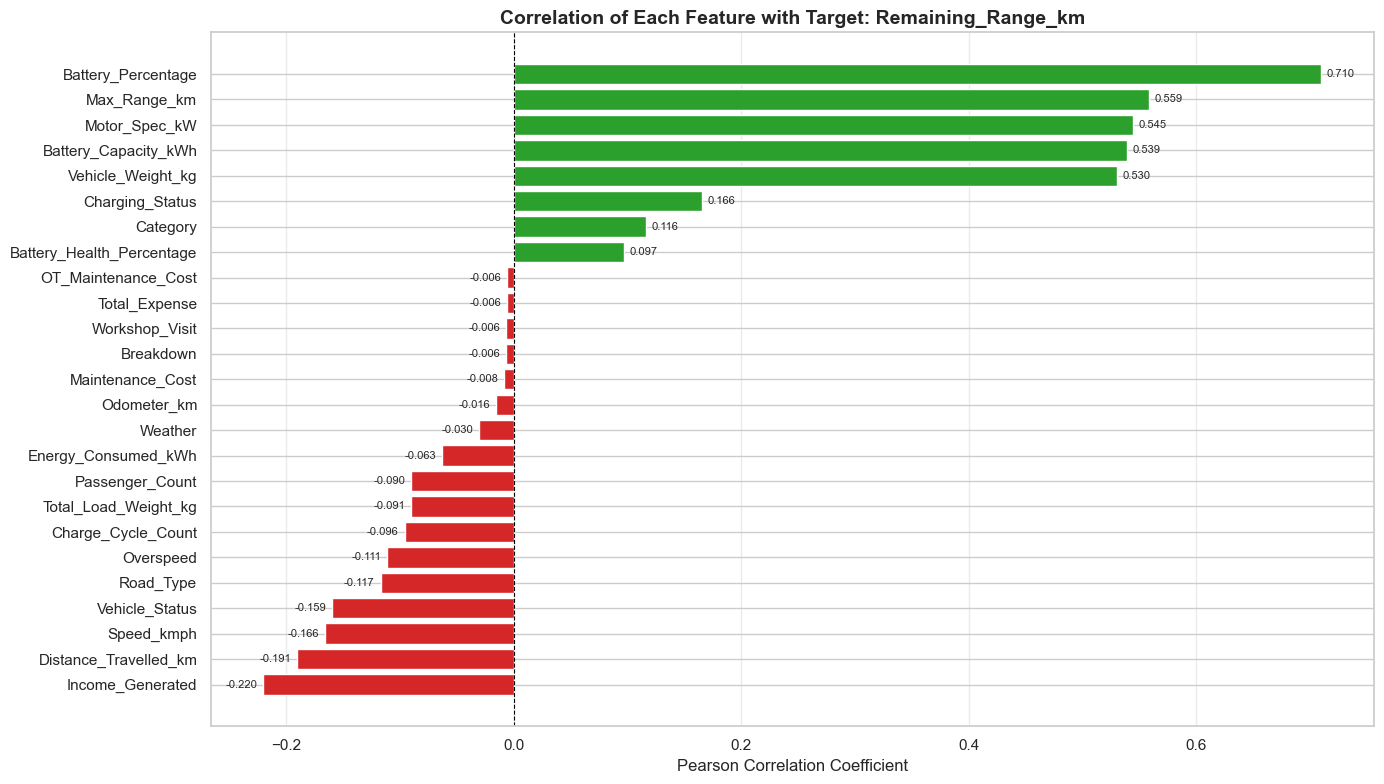


Top 10 positively correlated features:
Total_Expense               -0.006137
OT_Maintenance_Cost         -0.005712
Battery_Health_Percentage    0.096987
Category                     0.116131
Charging_Status              0.165714
Vehicle_Weight_kg            0.530455
Battery_Capacity_kWh         0.539033
Motor_Spec_kW                0.544852
Max_Range_km                 0.558799
Battery_Percentage           0.710111

Top 10 negatively correlated features:
Income_Generated        -0.220114
Distance_Travelled_km   -0.190622
Speed_kmph              -0.165722
Vehicle_Status          -0.159467
Road_Type               -0.117145
Overspeed               -0.111078
Charge_Cycle_Count      -0.096011
Total_Load_Weight_kg    -0.090610
Passenger_Count         -0.090412
Energy_Consumed_kWh     -0.063125


In [13]:
TARGET = 'Remaining_Range_km'

target_corr = corr_matrix[TARGET].drop(TARGET).sort_values()

# Color bars: red for negative, green for positive
colors = ['#d62728' if v < 0 else '#2ca02c' for v in target_corr.values]

plt.figure(figsize=(14, 8))
bars = plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.title(f'Correlation of Each Feature with Target: {TARGET}', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.4)

# Annotate each bar
for bar, val in zip(bars, target_corr.values):
    plt.text(val + (0.005 if val >= 0 else -0.005),
             bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

print("\nTop 10 positively correlated features:")
print(target_corr.tail(10).to_string())
print("\nTop 10 negatively correlated features:")
print(target_corr.head(10).to_string())

## 7. Feature and Target Split

In [14]:
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Features:     {X_train.shape[1]}")
print(f"Target:       {TARGET}")

Training set: 19360 samples
Test set:     4840 samples
Features:     25
Target:       Remaining_Range_km


## 8. Train Model 1: Linear Regression

Linear Regression R² Score: 0.7924


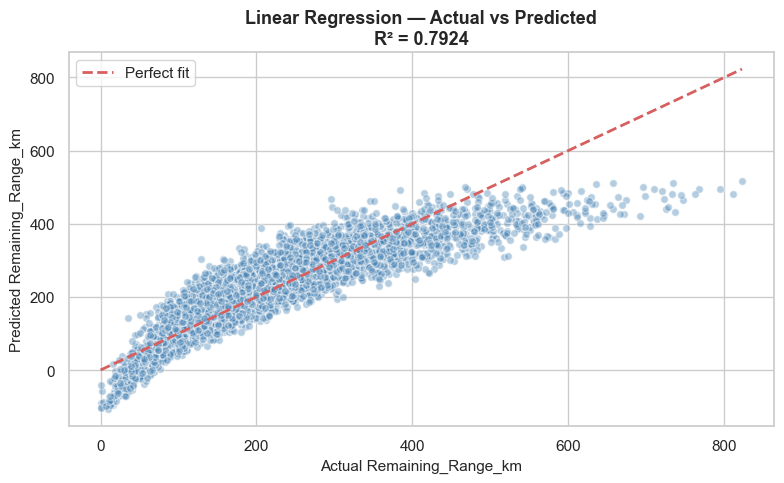

In [25]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression R² Score: {r2_lr:.4f}")

# Actual vs Predicted plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue', edgecolors='white', s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect fit')
plt.xlabel('Actual Remaining_Range_km', fontsize=11)
plt.ylabel('Predicted Remaining_Range_km', fontsize=11)
plt.title(f'Linear Regression — Actual vs Predicted\nR² = {r2_lr:.4f}', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Train Model 2: Random Forest Regressor

Random Forest Regressor R² Score: 0.8612


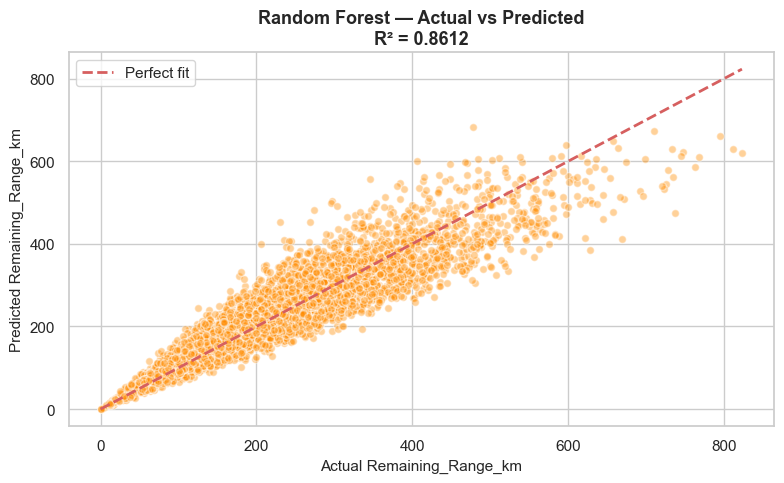

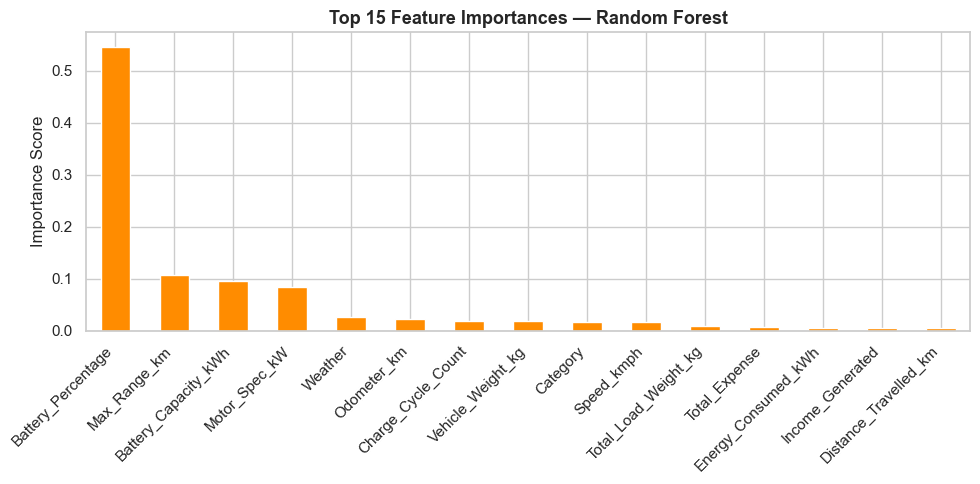

In [16]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest Regressor R² Score: {r2_rf:.4f}")

# Actual vs Predicted plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='darkorange', edgecolors='white', s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect fit')
plt.xlabel('Actual Remaining_Range_km', fontsize=11)
plt.ylabel('Predicted Remaining_Range_km', fontsize=11)
plt.title(f'Random Forest — Actual vs Predicted\nR² = {r2_rf:.4f}', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Feature importance
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Compare R² Scores

       Model Comparison — R² Score
            Model  R² Score
Linear Regression    0.7924
    Random Forest    0.8612

Best Model: Random Forest  (R² = 0.8612)


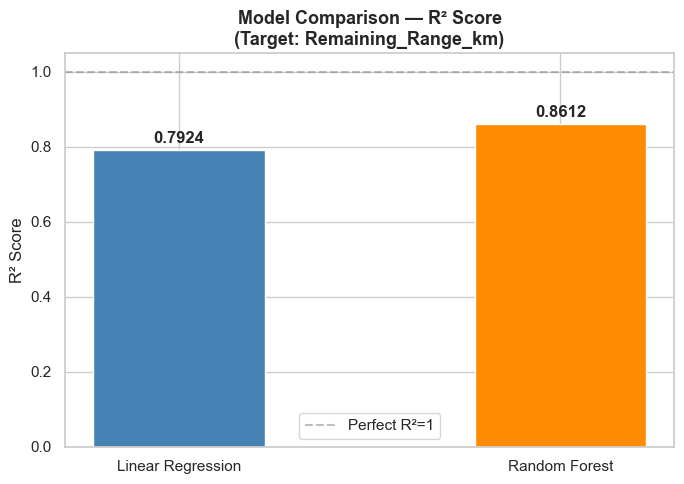

In [17]:
models = ['Linear Regression', 'Random Forest']
r2_scores = [r2_lr, r2_rf]
colors = ['steelblue', 'darkorange']

# Summary Table
summary_df = pd.DataFrame({
    'Model': models,
    'R² Score': [round(s, 4) for s in r2_scores]
})
print("=" * 35)
print("       Model Comparison — R² Score")
print("=" * 35)
print(summary_df.to_string(index=False))
print("=" * 35)
best = models[np.argmax(r2_scores)]
print(f"\nBest Model: {best}  (R² = {max(r2_scores):.4f})")

# Bar Chart Comparison
plt.figure(figsize=(7, 5))
bars = plt.bar(models, r2_scores, color=colors, edgecolor='white', width=0.45)
plt.ylim(0, 1.05)
plt.ylabel('R² Score', fontsize=12)
plt.title('Model Comparison — R² Score\n(Target: Remaining_Range_km)', fontsize=13, fontweight='bold')

for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.axhline(1.0, color='grey', linestyle='--', alpha=0.5, label='Perfect R²=1')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
import pickle

model_path = 'rf_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(rf_model, f)

print(f"Random Forest model saved to '{model_path}'")

Random Forest model saved to 'rf_model.pkl'


Records where Remaining_Range_km > Max_Range_km (anomalies): 0


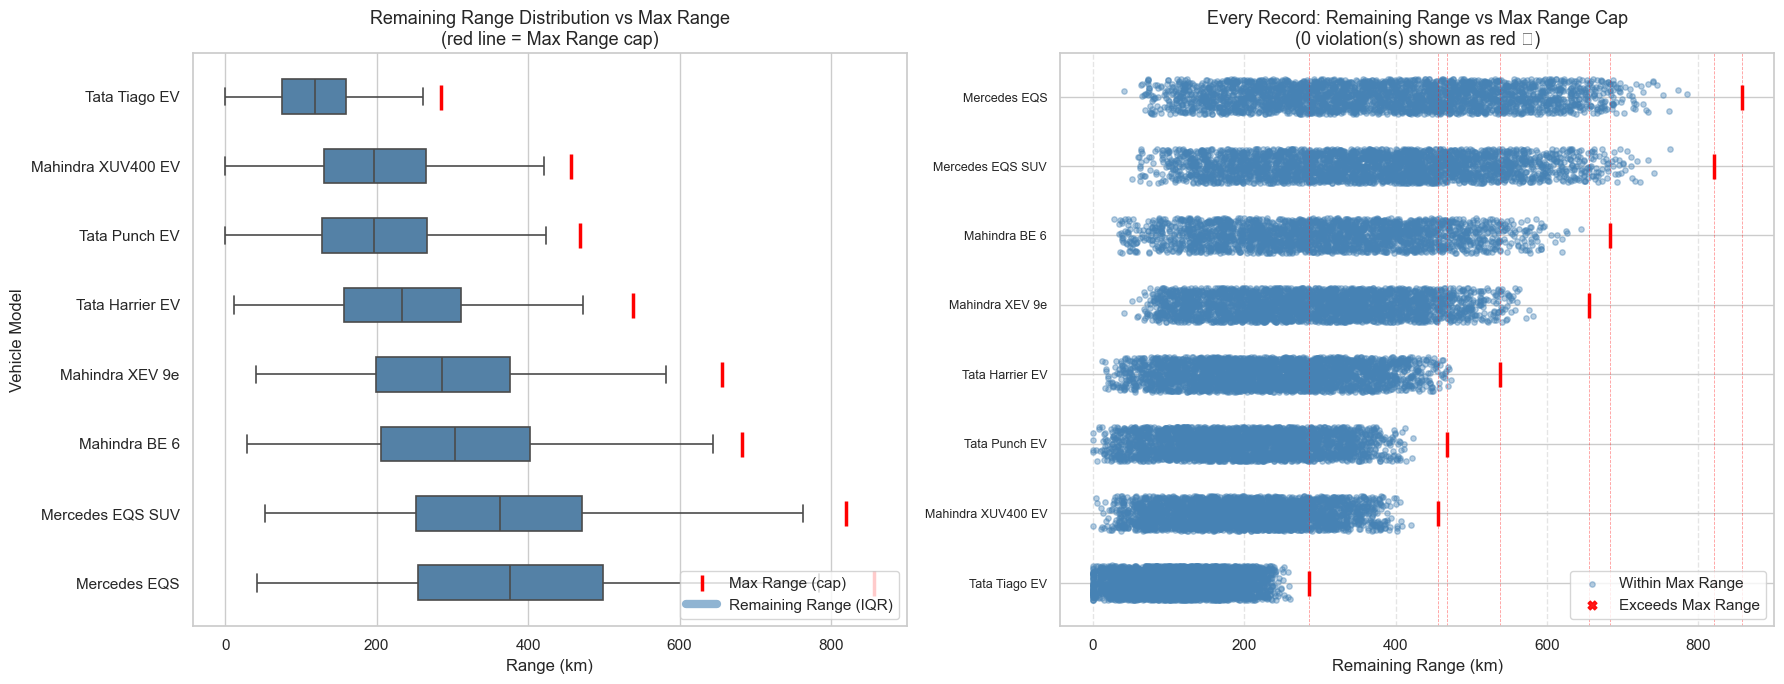

In [27]:

# ── Remaining Range vs Max Range per Vehicle Model ─────────────────────────
range_df = df[['Vehicle_Model', 'Max_Range_km', 'Remaining_Range_km']].copy()

# Flag records where remaining range exceeds max range (data anomalies)
range_df['exceeds_max'] = range_df['Remaining_Range_km'] > range_df['Max_Range_km']
violations = range_df['exceeds_max'].sum()
print(f"Records where Remaining_Range_km > Max_Range_km (anomalies): {violations}")
if violations > 0:
    print("\nViolating records:")
    print(range_df[range_df['exceeds_max']][['Vehicle_Model', 'Max_Range_km', 'Remaining_Range_km']])

# Per-model max range (should be constant per model)
model_max = range_df.groupby('Vehicle_Model')['Max_Range_km'].first().sort_values()
models_ordered = model_max.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Box plot of Remaining Range per model, with Max Range overlay ────
ax = axes[0]
range_df['Vehicle_Model'] = pd.Categorical(range_df['Vehicle_Model'],
                                            categories=models_ordered, ordered=True)
range_df_sorted = range_df.sort_values('Vehicle_Model')

sns.boxplot(
    data=range_df_sorted,
    x='Remaining_Range_km', y='Vehicle_Model',
    color='steelblue', width=0.5, linewidth=1.2, ax=ax
)

# Overlay Max_Range_km as a red vertical line per model
for i, model in enumerate(models_ordered):
    max_val = model_max[model]
    ax.plot(max_val, i, marker='|', color='red', markersize=18,
            markeredgewidth=2.5, zorder=5)

ax.set_title('Remaining Range Distribution vs Max Range\n(red line = Max Range cap)', fontsize=13)
ax.set_xlabel('Range (km)')
ax.set_ylabel('Vehicle Model')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='|', color='red', markersize=12,
           markeredgewidth=2.5, label='Max Range (cap)', linestyle='None'),
    Line2D([0], [0], color='steelblue', linewidth=6,
           label='Remaining Range (IQR)', alpha=0.6),
]
ax.legend(handles=legend_elements, loc='lower right')

# ── Right: Scatter – every data point coloured by violation status ─────────
ax2 = axes[1]

for i, model in enumerate(models_ordered):
    subset = range_df[range_df['Vehicle_Model'] == model]
    max_val = model_max[model]

    ok  = subset[~subset['exceeds_max']]
    bad = subset[subset['exceeds_max']]

    # Jitter on y-axis for readability
    jitter_ok  = np.random.uniform(-0.25, 0.25, size=len(ok))
    jitter_bad = np.random.uniform(-0.25, 0.25, size=len(bad))

    ax2.scatter(ok['Remaining_Range_km'],  i + jitter_ok,
                color='steelblue', alpha=0.4, s=15, label='Within Max Range' if i == 0 else '')
    ax2.scatter(bad['Remaining_Range_km'], i + jitter_bad,
                color='red', alpha=0.9, s=40, marker='X', zorder=5,
                label='Exceeds Max Range' if i == 0 else '')

    # Max range cap line
    ax2.axvline(x=max_val, color='red', linestyle='--', linewidth=0.6, alpha=0.4)
    # One solid cap marker per model
    ax2.plot(max_val, i, marker='|', color='red', markersize=18, markeredgewidth=2.5, zorder=6)

ax2.set_yticks(range(len(models_ordered)))
ax2.set_yticklabels(models_ordered, fontsize=9)
ax2.set_xlabel('Remaining Range (km)')
ax2.set_title(f'Every Record: Remaining Range vs Max Range Cap\n'
              f'({violations} violation(s) shown as red ✕)', fontsize=13)
ax2.legend(loc='lower right')
ax2.xaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
